# 04 Review Signal PoC

## Scope

Create item-level review-text signal features.

Pipeline data outputs:

```text
data/processed/review_signals.csv
data/processed/review_signal_handoff.csv
```

Notebook-specific diagnostics and plots:

```text
outputs/04_review_signal_poc/
```


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "notebooks").exists() and (path / "data").exists():
            return path
    if current.name == "notebooks":
        return current.parent
    return current


REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / "data" / "raw" / "clothing_fit"
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
OUTPUTS_DIR = REPO_ROOT / "outputs"
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / "04_review_signal_poc"
PLOTS_DIR = NOTEBOOK_OUTPUT_DIR / "plots"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILES = [
    ("modcloth", RAW_DIR / "modcloth_final_data.json"),
    ("renttherunway", RAW_DIR / "renttherunway_final_data.json"),
]

OUTPUT_PATH = PROCESSED_DIR / "review_signals.csv"
HANDOFF_PATH = PROCESSED_DIR / "review_signal_handoff.csv"
DIAGNOSTICS_PATH = NOTEBOOK_OUTPUT_DIR / "review_signal_diagnostics.csv"

print("Repo root:", REPO_ROOT)
print("Raw dir:", RAW_DIR)
print("Output path:", OUTPUT_PATH)
print("Notebook output dir:", NOTEBOOK_OUTPUT_DIR)
print("Plots dir:", PLOTS_DIR)


Repo root: C:\Users\monster\Desktop\returnshield-ai
Raw dir: C:\Users\monster\Desktop\returnshield-ai\data\raw\clothing_fit
Output path: C:\Users\monster\Desktop\returnshield-ai\data\processed\review_signals.csv
Notebook output dir: C:\Users\monster\Desktop\returnshield-ai\outputs\04_review_signal_poc
Plots dir: C:\Users\monster\Desktop\returnshield-ai\outputs\04_review_signal_poc\plots


## 1. Load available input files

Each input file is checked separately.

Missing files are skipped. At least one Clothing Fit input file is required.


In [2]:
def load_json_records(path: Path) -> pd.DataFrame:
    """Load JSON-lines, JSON array, or concatenated JSON objects into a DataFrame."""
    path = Path(path)

    try:
        return pd.read_json(path, lines=True)
    except ValueError:
        pass

    try:
        return pd.read_json(path)
    except ValueError:
        pass

    records = []
    decoder = json.JSONDecoder()
    text = path.read_text(encoding="utf-8")
    idx = 0
    n = len(text)

    while idx < n:
        while idx < n and text[idx].isspace():
            idx += 1
        if idx >= n:
            break
        obj, end = decoder.raw_decode(text, idx)
        records.append(obj)
        idx = end

    return pd.DataFrame(records)


def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df


def normalize_dataset(df: pd.DataFrame, source: str) -> pd.DataFrame:
    """Normalize the columns needed for review-text signal extraction."""
    df = clean_columns(df)
    df["source"] = source

    required_columns = [
        "item_id",
        "user_id",
        "category",
        "fit",
        "length",
        "quality",
        "rating",
        "review_summary",
        "review_text",
    ]

    for col in required_columns:
        if col not in df.columns:
            df[col] = np.nan

    return df[["source", *required_columns]].copy()


loaded_frames = []
load_report = []

for source, path in INPUT_FILES:
    if not path.exists():
        load_report.append({"source": source, "path": str(path), "status": "missing", "rows": 0})
        print(f"Skipping missing file: {path}")
        continue

    raw_df = load_json_records(path)
    normalized_df = normalize_dataset(raw_df, source)
    loaded_frames.append(normalized_df)
    load_report.append({"source": source, "path": str(path), "status": "loaded", "rows": len(normalized_df)})
    print(f"Loaded {source}: {normalized_df.shape}")

if not loaded_frames:
    expected = "\n".join(str(path) for _, path in INPUT_FILES)
    raise FileNotFoundError(
        "No Clothing Fit input files were found. Expected at least one of:\n" + expected
    )

reviews_df = pd.concat(loaded_frames, ignore_index=True)

load_report_df = pd.DataFrame(load_report)
print("Combined shape:", reviews_df.shape)

load_report_df


Loaded modcloth: (82790, 10)
Loaded renttherunway: (192544, 10)
Combined shape: (275334, 10)


,source,path,status,rows
0,modcloth,C:\Users\monster\Desktop\returnshield-ai\data\...,loaded,82790
1,renttherunway,C:\Users\monster\Desktop\returnshield-ai\data\...,loaded,192544


## 2. Prepare review text

`review_summary` and `review_text` are joined into one text field.

Rows with empty joined text are left out of item-level text aggregation. Missing text stays missing.


In [3]:
def normalize_text(series: pd.Series) -> pd.Series:
    return (
        series.fillna("")
        .astype(str)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


reviews_df["review_text_combined"] = (
    normalize_text(reviews_df["review_summary"]) + " " + normalize_text(reviews_df["review_text"])
).str.strip()

reviews_df["has_review_text"] = reviews_df["review_text_combined"].str.len().gt(0)

coverage = (
    reviews_df
    .groupby("source")
    .agg(
        rows=("item_id", "size"),
        rows_with_review_text=("has_review_text", "sum"),
        review_text_share=("has_review_text", "mean"),
        unique_items=("item_id", "nunique"),
    )
    .reset_index()
)

coverage


,source,rows,rows_with_review_text,review_text_share,unique_items
0,modcloth,82790,76065,0.91877,1378
1,renttherunway,192544,192542,0.99999,5850


## 3. Keyword groups

Keyword rules are used as a Sprint 1 PoC.

Output fields use the `review_text_*` prefix so they do not overlap with the structured fit columns from Notebook 03.


In [4]:
ISSUE_TERMS = {
    "size": [
        "too small", "runs small", "run small", "ran small",
        "tight", "snug", "size up", "sized up",
        "too big", "too large", "runs large", "run large", "ran large",
        "loose", "baggy", "size down", "sized down",
        "did not fit", "didn't fit", "fit issue", "fit problem"
    ],
    "quality": [
        "poor quality", "low quality", "bad quality", "cheap", "cheaply made",
        "thin fabric", "bad fabric", "poor fabric", "scratchy", "itchy",
        "see through", "see-through", "ripped", "torn", "hole",
        "broken zipper", "stained", "worn out", "fabric was thin"
    ],
    "color": [
        "different color", "color is different", "color was different",
        "not as pictured", "not like the picture", "not like picture",
        "color is off", "color was off", "faded",
        "lighter than pictured", "darker than pictured", "not the color"
    ],
    "negative": [
        "uncomfortable", "disappointed", "poor", "bad", "cheap", "itchy",
        "scratchy", "tight", "loose", "small", "large", "ripped", "torn",
        "problem", "issue", "would not rent", "wouldn't rent",
        "did not fit", "didn't fit", "not flattering"
    ],
    "positive": [
        "perfect", "great", "love", "loved", "comfortable", "amazing",
        "flattering", "compliments", "recommend", "beautiful",
        "fit perfectly", "true to size", "good quality"
    ],
}


def make_phrase_pattern(terms):
    escaped = [re.escape(term) for term in terms]
    return re.compile(r"(?:" + "|".join(escaped) + r")", flags=re.IGNORECASE)


PATTERNS = {key: make_phrase_pattern(terms) for key, terms in ISSUE_TERMS.items()}

for key in ["size", "quality", "color", "negative", "positive"]:
    reviews_df[f"{key}_keyword_count"] = reviews_df["review_text_combined"].apply(
        lambda text: len(PATTERNS[key].findall(text)) if isinstance(text, str) else 0
    )

reviews_df["review_text_size_issue_flag"] = (
    (reviews_df["size_keyword_count"] > 0) & reviews_df["has_review_text"]
).astype(int)

reviews_df["review_text_quality_issue_flag"] = (
    (reviews_df["quality_keyword_count"] > 0) & reviews_df["has_review_text"]
).astype(int)

reviews_df["review_text_color_issue_flag"] = (
    (reviews_df["color_keyword_count"] > 0) & reviews_df["has_review_text"]
).astype(int)

reviews_df["review_text_negative_language_score"] = np.where(
    reviews_df["has_review_text"],
    reviews_df["negative_keyword_count"] / (
        reviews_df["negative_keyword_count"] + reviews_df["positive_keyword_count"] + 1
    ),
    np.nan,
)

reviews_df[
    [
        "source",
        "item_id",
        "review_text_combined",
        "review_text_size_issue_flag",
        "review_text_quality_issue_flag",
        "review_text_color_issue_flag",
        "review_text_negative_language_score",
    ]
].head()


,source,item_id,review_text_combined,review_text_size_issue_flag,review_text_quality_issue_flag,review_text_color_issue_flag,review_text_negative_language_score
0,modcloth,123373,,0,0,0,NaN
1,modcloth,123373,,0,0,0,NaN
2,modcloth,123373,,0,0,0,NaN
3,modcloth,123373,,0,0,0,NaN
4,modcloth,123373,,0,0,0,NaN


## 4. Rating issue score

Ratings are converted into an issue-oriented score when the field is available.

- Lower rating means higher issue score.
- Missing rating stays missing.
- Missing rating evidence is not converted into low risk.


In [5]:
reviews_df["rating_numeric"] = pd.to_numeric(reviews_df["rating"], errors="coerce")

source_rating_max = reviews_df.groupby("source")["rating_numeric"].transform("max")
source_rating_min = reviews_df.groupby("source")["rating_numeric"].transform("min")
rating_span = (source_rating_max - source_rating_min).replace(0, np.nan)

reviews_df["rating_issue_score"] = 1 - (
    (reviews_df["rating_numeric"] - source_rating_min) / rating_span
)

reviews_df["rating_issue_score"] = reviews_df["rating_issue_score"].clip(0, 1)
reviews_df.loc[reviews_df["rating_numeric"].isna(), "rating_issue_score"] = np.nan

diagnostics = {
    "total_rows": len(reviews_df),
    "rows_with_review_text": int(reviews_df["has_review_text"].sum()),
    "rows_with_rating": int(reviews_df["rating_numeric"].notna().sum()),
    "text_size_issue_flag_rate": float(reviews_df.loc[reviews_df["has_review_text"], "review_text_size_issue_flag"].mean()),
    "text_quality_issue_flag_rate": float(reviews_df.loc[reviews_df["has_review_text"], "review_text_quality_issue_flag"].mean()),
    "text_color_issue_flag_rate": float(reviews_df.loc[reviews_df["has_review_text"], "review_text_color_issue_flag"].mean()),
}

diagnostics


{'total_rows': 275334,
 'rows_with_review_text': 268607,
 'rows_with_rating': 192462,
 'text_size_issue_flag_rate': 0.3030859210668374,
 'text_quality_issue_flag_rate': 0.05534852032895643,
 'text_color_issue_flag_rate': 0.004940303119427268}

## 5. Aggregate review-text signals at item level

Signals are aggregated by `source` and `item_id`.

Including `source` prevents item ID collisions between ModCloth and RentTheRunway.


In [6]:
review_rows = reviews_df[reviews_df["has_review_text"]].copy()

if review_rows.empty:
    raise ValueError("No review text found in the available input file(s). Cannot create review_signals.csv.")

group_cols = ["source", "item_id"]

global_text_rates = {
    "review_text_size_issue_score": review_rows["review_text_size_issue_flag"].mean(),
    "review_text_quality_issue_score": review_rows["review_text_quality_issue_flag"].mean(),
    "review_text_color_issue_score": review_rows["review_text_color_issue_flag"].mean(),
    "review_text_negative_language_score": review_rows["review_text_negative_language_score"].mean(skipna=True),
}

rating_available = review_rows["rating_issue_score"].notna()
global_rating_issue_score = review_rows.loc[rating_available, "rating_issue_score"].mean()

review_signals = (
    review_rows
    .groupby(group_cols)
    .agg(
        review_text_count=("review_text_combined", "size"),
        unique_review_users=("user_id", "nunique"),
        rating_count=("rating_numeric", "count"),
        avg_rating=("rating_numeric", "mean"),
        raw_review_text_size_issue_rate=("review_text_size_issue_flag", "mean"),
        raw_review_text_quality_issue_rate=("review_text_quality_issue_flag", "mean"),
        raw_review_text_color_issue_rate=("review_text_color_issue_flag", "mean"),
        raw_review_text_negative_language_score=("review_text_negative_language_score", "mean"),
        raw_rating_issue_score=("rating_issue_score", "mean"),
        size_keyword_total=("size_keyword_count", "sum"),
        quality_keyword_total=("quality_keyword_count", "sum"),
        color_keyword_total=("color_keyword_count", "sum"),
    )
    .reset_index()
)

ALPHA_REVIEW_TEXT = float(review_signals["review_text_count"].mean())

rating_positive_counts = review_signals.loc[review_signals["rating_count"] > 0, "rating_count"]
ALPHA_RATING = float(rating_positive_counts.mean()) if not rating_positive_counts.empty else 0.0

print("Review-text smoothing alpha:", round(ALPHA_REVIEW_TEXT, 4))
print("Rating smoothing alpha:", round(ALPHA_RATING, 4))


def smooth_rate(raw_rate, count, global_rate, alpha):
    return ((raw_rate * count) + (global_rate * alpha)) / (count + alpha)


for final_col, raw_col in [
    ("review_text_size_issue_score", "raw_review_text_size_issue_rate"),
    ("review_text_quality_issue_score", "raw_review_text_quality_issue_rate"),
    ("review_text_color_issue_score", "raw_review_text_color_issue_rate"),
    ("review_text_negative_language_score", "raw_review_text_negative_language_score"),
]:
    review_signals[final_col] = smooth_rate(
        review_signals[raw_col],
        review_signals["review_text_count"],
        global_text_rates[final_col],
        ALPHA_REVIEW_TEXT,
    ).clip(0, 1)

review_signals["review_text_reliability_weight"] = (
    review_signals["review_text_count"] / (review_signals["review_text_count"] + ALPHA_REVIEW_TEXT)
).clip(0, 1)

review_signals["rating_signal_reliability_weight"] = np.where(
    review_signals["rating_count"] > 0,
    review_signals["rating_count"] / (review_signals["rating_count"] + ALPHA_RATING),
    0.0,
)

review_signals["rating_issue_score"] = np.where(
    review_signals["rating_count"] > 0,
    smooth_rate(
        review_signals["raw_rating_issue_score"],
        review_signals["rating_count"],
        global_rating_issue_score,
        ALPHA_RATING,
    ).clip(0, 1),
    np.nan,
)

review_signals["source_item_id"] = (
    review_signals["source"].astype(str) + "_" + review_signals["item_id"].astype(str)
)

issue_score_cols = [
    "review_text_size_issue_score",
    "review_text_quality_issue_score",
    "review_text_color_issue_score",
    "review_text_negative_language_score",
    "rating_issue_score",
]

reason_map = {
    "review_text_size_issue_score": "review_text_size_issue",
    "review_text_quality_issue_score": "review_text_quality_issue",
    "review_text_color_issue_score": "review_text_color_issue",
    "review_text_negative_language_score": "negative_review_language",
    "rating_issue_score": "low_rating_signal",
}

review_signals["top_review_text_issue"] = (
    review_signals[issue_score_cols]
    .fillna(-1)
    .idxmax(axis=1)
    .map(reason_map)
)

output_columns = [
    "source_item_id",
    "source",
    "item_id",
    "review_text_count",
    "unique_review_users",
    "rating_count",
    "avg_rating",
    "review_text_reliability_weight",
    "rating_signal_reliability_weight",
    "review_text_size_issue_score",
    "review_text_quality_issue_score",
    "review_text_color_issue_score",
    "review_text_negative_language_score",
    "rating_issue_score",
    "top_review_text_issue",
    "size_keyword_total",
    "quality_keyword_total",
    "color_keyword_total",
    "raw_review_text_size_issue_rate",
    "raw_review_text_quality_issue_rate",
    "raw_review_text_color_issue_rate",
    "raw_review_text_negative_language_score",
    "raw_rating_issue_score",
]

review_signals = (
    review_signals[output_columns]
    .sort_values(["review_text_reliability_weight", "review_text_count"], ascending=False)
    .reset_index(drop=True)
)

print("Review signals shape:", review_signals.shape)
review_signals.head(10)


Review-text smoothing alpha: 37.4417
Rating smoothing alpha: 32.8991
Review signals shape: (7174, 23)


,source_item_id,source,item_id,review_text_count,unique_review_users,rating_count,avg_rating,review_text_reliability_weight,rating_signal_reliability_weight,review_text_size_issue_score,review_text_quality_issue_score,review_text_color_issue_score,review_text_negative_language_score,rating_issue_score,top_review_text_issue,size_keyword_total,quality_keyword_total,color_keyword_total,raw_review_text_size_issue_rate,raw_review_text_quality_issue_rate,raw_review_text_color_issue_rate,raw_review_text_negative_language_score,raw_rating_issue_score
0,renttherunway_126335,renttherunway,126335,2241,2239,2231,8.960108,0.983567,0.985468,0.241107,0.102295,0.002276,0.136121,0.129746,review_text_size_issue,708,251,5,0.240071,0.103079,0.002231,0.136140,0.129987
1,modcloth_539980,modcloth,539980,2008,1969,0,NaN,0.981695,0.000000,0.176660,0.034747,0.020624,0.093364,NaN,review_text_size_issue,505,83,42,0.174303,0.034363,0.020916,0.092587,NaN
2,renttherunway_174086,renttherunway,174086,1724,1724,1724,9.013921,0.978744,0.981274,0.340260,0.045458,0.005214,0.114030,0.123076,review_text_size_issue,800,82,9,0.341067,0.045244,0.005220,0.113574,0.123260
3,renttherunway_123793,renttherunway,123793,1714,1713,1714,9.537923,0.978622,0.981167,0.217163,0.074837,0.002389,0.097212,0.058808,review_text_size_issue,472,140,4,0.215286,0.075263,0.002334,0.096386,0.057760
4,renttherunway_132738,renttherunway,132738,1582,1582,1577,9.232720,0.976880,0.979564,0.273766,0.078467,0.002584,0.140572,0.096268,review_text_size_issue,568,137,4,0.273072,0.079014,0.002528,0.140703,0.095910
5,modcloth_668696,modcloth,668696,1555,1544,0,NaN,0.976488,0.000000,0.293479,0.023280,0.004512,0.153971,NaN,review_text_size_issue,660,41,8,0.293248,0.022508,0.004502,0.154427,NaN
6,modcloth_397005,modcloth,397005,1506,1477,0,NaN,0.975741,0.000000,0.275584,0.063541,0.013078,0.132619,NaN,review_text_size_issue,543,113,20,0.274900,0.063745,0.013280,0.132559,NaN
7,renttherunway_145906,renttherunway,145906,1478,1478,1472,9.012228,0.975293,0.978139,0.234485,0.038320,0.001442,0.109047,0.123252,review_text_size_issue,448,60,2,0.232747,0.037889,0.001353,0.108389,0.123471
8,modcloth_175771,modcloth,175771,1438,1419,0,NaN,0.974623,0.000000,0.272019,0.046137,0.015714,0.133420,NaN,review_text_size_issue,530,79,23,0.271210,0.045897,0.015994,0.133378,NaN
9,modcloth_407134,modcloth,407134,1437,1410,0,NaN,0.974606,0.000000,0.259995,0.182491,0.006908,0.188485,NaN,review_text_size_issue,578,355,10,0.258873,0.185804,0.006959,0.189878,NaN


## 6. Save output

Write the local output file under `data/processed/`.

The folder is excluded by `.gitignore`.


In [7]:
review_signals.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print("Shape:", review_signals.shape)

summary = review_signals[
    [
        "review_text_count",
        "review_text_reliability_weight",
        "review_text_size_issue_score",
        "review_text_quality_issue_score",
        "review_text_color_issue_score",
        "review_text_negative_language_score",
        "rating_issue_score",
    ]
].describe()

summary


Saved: C:\Users\monster\Desktop\returnshield-ai\data\processed\review_signals.csv
Shape: (7174, 23)


,review_text_count,review_text_reliability_weight,review_text_size_issue_score,review_text_quality_issue_score,review_text_color_issue_score,review_text_negative_language_score,rating_issue_score
count,7174.000000,7174.000000,7174.000000,7174.000000,7174.000000,7174.000000,5850.000000
mean,37.441734,0.295958,0.307759,0.054258,0.004462,0.136386,0.114997
std,108.620463,0.238005,0.050417,0.021484,0.004231,0.020252,0.022714
min,1.000000,0.026013,0.100921,0.013218,0.000256,0.053843,0.036233
25%,4.000000,0.096521,0.280603,0.042780,0.002962,0.125010,0.102326
50%,12.000000,0.242710,0.302435,0.051243,0.003983,0.134409,0.111674
75%,30.000000,0.444828,0.330057,0.059366,0.004574,0.145962,0.124937
max,2241.000000,0.983567,0.691984,0.431769,0.080308,0.298444,0.266143


## 7. Consistency checks

Basic checks for file creation, unique keys, and score ranges.


In [8]:
assert OUTPUT_PATH.exists(), "Output file was not created."
assert review_signals["source_item_id"].is_unique, "source_item_id should be unique."
assert review_signals["review_text_count"].min() >= 1, "Every output row should have at least one review text."

score_columns = [
    "review_text_reliability_weight",
    "rating_signal_reliability_weight",
    "review_text_size_issue_score",
    "review_text_quality_issue_score",
    "review_text_color_issue_score",
    "review_text_negative_language_score",
    "rating_issue_score",
]

for col in score_columns:
    non_missing = review_signals[col].dropna()
    assert non_missing.between(0, 1).all(), f"{col} contains values outside [0, 1]."

print("Consistency checks passed.")


Consistency checks passed.


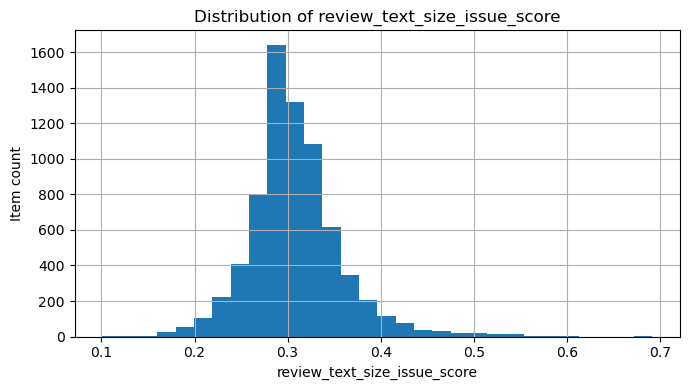

Saved plot: C:\Users\monster\Desktop\returnshield-ai\outputs\04_review_signal_poc\plots\review_text_size_issue_score_distribution.png


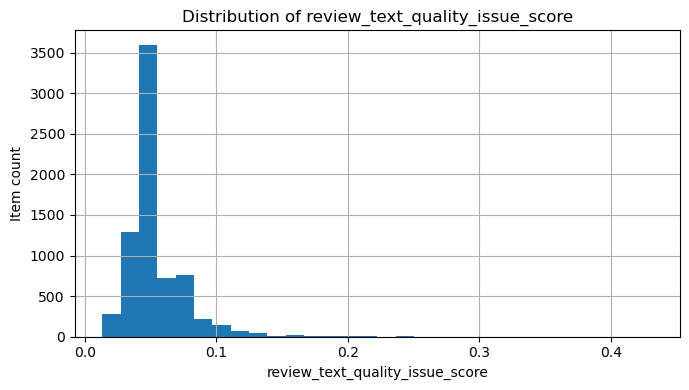

Saved plot: C:\Users\monster\Desktop\returnshield-ai\outputs\04_review_signal_poc\plots\review_text_quality_issue_score_distribution.png


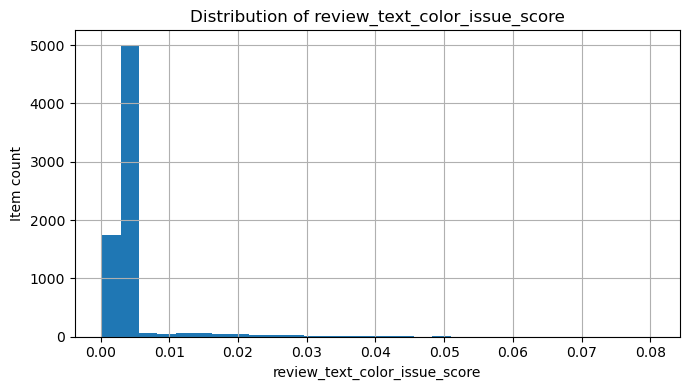

Saved plot: C:\Users\monster\Desktop\returnshield-ai\outputs\04_review_signal_poc\plots\review_text_color_issue_score_distribution.png


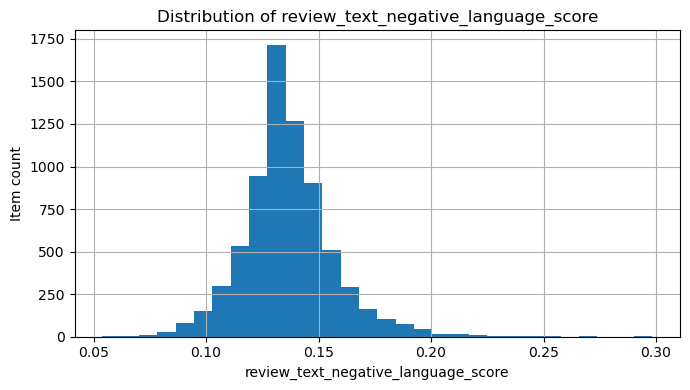

Saved plot: C:\Users\monster\Desktop\returnshield-ai\outputs\04_review_signal_poc\plots\review_text_negative_language_score_distribution.png


In [9]:
# Optional quick plots

plot_cols = [
    "review_text_size_issue_score",
    "review_text_quality_issue_score",
    "review_text_color_issue_score",
    "review_text_negative_language_score",
]

for col in plot_cols:
    plt.figure(figsize=(7, 4))
    review_signals[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Item count")
    plt.tight_layout()
    plot_path = PLOTS_DIR / f"{col}_distribution.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved plot:", plot_path)


## 8. Signal diagnostics

Before Notebook 05, each review-text signal is checked for spread and coverage.

This section is diagnostic only. It does not create model weights and it does not decide the final Risk Agent formula. The goal is to show which signals actually separate items and which ones should stay as weak or explanation-only signals.


In [10]:
# Diagnostic table for Notebook 05.
# These values describe spread and coverage. They are not model weights.

utility_signal_cols = [
    "review_text_size_issue_score",
    "review_text_quality_issue_score",
    "review_text_color_issue_score",
    "review_text_negative_language_score",
    "rating_issue_score",
]

diagnostic_rows = []

for col in utility_signal_cols:
    s = review_signals[col].dropna()
    if s.empty:
        diagnostic_rows.append({
            "signal": col,
            "non_missing_share": 0.0,
            "nonzero_share": 0.0,
            "mean": np.nan,
            "std": np.nan,
            "p50": np.nan,
            "p75": np.nan,
            "p90": np.nan,
            "p95": np.nan,
            "p99": np.nan,
            "p95_minus_p50": np.nan,
            "p99_minus_p50": np.nan,
            "spread_coverage_index": 0.0,
            "diagnostic_rank": np.nan,
        })
        continue

    p50 = s.quantile(0.50)
    p75 = s.quantile(0.75)
    p90 = s.quantile(0.90)
    p95 = s.quantile(0.95)
    p99 = s.quantile(0.99)

    non_missing_share = len(s) / len(review_signals)
    nonzero_share = (s > 0).mean()
    p95_minus_p50 = p95 - p50
    p99_minus_p50 = p99 - p50

    # Descriptive index only:
    # higher when a signal has both item-level spread and dataset coverage.
    # It is exported for inspection, not as a Risk Agent weight.
    spread_coverage_index = max(float(p95_minus_p50), 0.0) * float(non_missing_share)

    diagnostic_rows.append({
        "signal": col,
        "non_missing_share": non_missing_share,
        "nonzero_share": nonzero_share,
        "mean": s.mean(),
        "std": s.std(),
        "p50": p50,
        "p75": p75,
        "p90": p90,
        "p95": p95,
        "p99": p99,
        "p95_minus_p50": p95_minus_p50,
        "p99_minus_p50": p99_minus_p50,
        "spread_coverage_index": spread_coverage_index,
        "diagnostic_rank": np.nan,
    })

signal_diagnostics = pd.DataFrame(diagnostic_rows)

signal_diagnostics["diagnostic_rank"] = (
    signal_diagnostics["spread_coverage_index"]
    .rank(method="dense", ascending=False)
    .astype("Int64")
)

signal_diagnostics = signal_diagnostics.sort_values(
    ["diagnostic_rank", "spread_coverage_index"],
    ascending=[True, False],
).reset_index(drop=True)

DIAGNOSTICS_PATH = NOTEBOOK_OUTPUT_DIR / "review_signal_diagnostics.csv"
signal_diagnostics.to_csv(DIAGNOSTICS_PATH, index=False)

print("Saved diagnostics:", DIAGNOSTICS_PATH)
signal_diagnostics


Saved diagnostics: C:\Users\monster\Desktop\returnshield-ai\outputs\04_review_signal_poc\review_signal_diagnostics.csv


,signal,non_missing_share,nonzero_share,mean,std,p50,p75,p90,p95,p99,p95_minus_p50,p99_minus_p50,spread_coverage_index,diagnostic_rank
0,review_text_size_issue_score,1.000000,1.0,0.307759,0.050417,0.302435,0.330057,0.366457,0.393252,0.479182,0.090816,0.176747,0.090816,1
1,review_text_quality_issue_score,1.000000,1.0,0.054258,0.021484,0.051243,0.059366,0.077896,0.093743,0.132806,0.042500,0.081563,0.042500,2
2,review_text_negative_language_score,1.000000,1.0,0.136386,0.020252,0.134409,0.145962,0.160092,0.172060,0.197493,0.037651,0.063084,0.037651,3
3,rating_issue_score,0.815445,1.0,0.114997,0.022714,0.111674,0.124937,0.144171,0.156220,0.183525,0.044546,0.071851,0.036325,4
4,review_text_color_issue_score,1.000000,1.0,0.004462,0.004231,0.003983,0.004574,0.004812,0.009412,0.026315,0.005429,0.022332,0.005429,5


## 9. High-signal flags

Some signals may be rare but still useful for explanations.

The flags below use each signal's own empirical upper tail. They are not model weights. Notebook 05 can use them as explanation triggers, especially for narrow signals such as color issue.


In [11]:
# Empirical upper-tail flags.
# These flags help preserve rare but meaningful review issues without turning them into large continuous weights.

tail_signal_cols = [
    "review_text_size_issue_score",
    "review_text_quality_issue_score",
    "review_text_color_issue_score",
    "review_text_negative_language_score",
]

for col in tail_signal_cols:
    values = review_signals[col].dropna()
    if values.empty:
        review_signals[f"{col}_upper_tail_flag"] = 0
        continue

    threshold = values.quantile(0.95)
    review_signals[f"{col}_upper_tail_flag"] = (
        (review_signals[col] >= threshold) & review_signals[col].notna()
    ).astype(int)

# Save the final review signal file after adding flags.
review_signals.to_csv(OUTPUT_PATH, index=False)

print("Updated:", OUTPUT_PATH)

review_signals[
    [
        "source_item_id",
        "review_text_count",
        "review_text_size_issue_score",
        "review_text_quality_issue_score",
        "review_text_color_issue_score",
        "review_text_negative_language_score",
        "review_text_color_issue_score_upper_tail_flag",
        "top_review_text_issue",
    ]
].head(10)


Updated: C:\Users\monster\Desktop\returnshield-ai\data\processed\review_signals.csv


,source_item_id,review_text_count,review_text_size_issue_score,review_text_quality_issue_score,review_text_color_issue_score,review_text_negative_language_score,review_text_color_issue_score_upper_tail_flag,top_review_text_issue
0,renttherunway_126335,2241,0.241107,0.102295,0.002276,0.136121,0,review_text_size_issue
1,modcloth_539980,2008,0.176660,0.034747,0.020624,0.093364,1,review_text_size_issue
2,renttherunway_174086,1724,0.340260,0.045458,0.005214,0.114030,0,review_text_size_issue
3,renttherunway_123793,1714,0.217163,0.074837,0.002389,0.097212,0,review_text_size_issue
4,renttherunway_132738,1582,0.273766,0.078467,0.002584,0.140572,0,review_text_size_issue
5,modcloth_668696,1555,0.293479,0.023280,0.004512,0.153971,0,review_text_size_issue
6,modcloth_397005,1506,0.275584,0.063541,0.013078,0.132619,1,review_text_size_issue
7,renttherunway_145906,1478,0.234485,0.038320,0.001442,0.109047,0,review_text_size_issue
8,modcloth_175771,1438,0.272019,0.046137,0.015714,0.133420,1,review_text_size_issue
9,modcloth_407134,1437,0.259995,0.182491,0.006908,0.188485,0,review_text_size_issue


## 10. Notebook 05 handoff

The table below turns the diagnostic results into integration notes for Notebook 05.

No fixed numeric threshold is used here. The notes come from relative diagnostics:

- largest spread/coverage signal: main review-text candidate,
- lowest spread/coverage signal: flag/explanation candidate,
- lower coverage than the review-text columns: conditional signal,
- remaining signals: supporting candidates.

These notes are not learned weights. Notebook 05 should still combine the signals in the Risk Agent step.


In [12]:
# Handoff notes for Notebook 05.
# This table is derived from diagnostic rank and coverage. It is not a scoring formula.

handoff = signal_diagnostics.copy()

max_coverage = handoff["non_missing_share"].max()
best_rank = handoff["diagnostic_rank"].min()
last_rank = handoff["diagnostic_rank"].max()

def assign_notebook05_usage(row):
    signal = row["signal"]

    if row["non_missing_share"] < max_coverage:
        return "conditional_supporting_signal"

    if row["diagnostic_rank"] == best_rank:
        return "main_review_text_signal"

    if row["diagnostic_rank"] == last_rank:
        return "flag_or_explanation_signal"

    return "supporting_review_text_signal"


def write_usage_note(row):
    usage = row["notebook05_usage"]

    if usage == "main_review_text_signal":
        return "Use as the main continuous review-text signal if the Risk Agent needs one review feature."

    if usage == "conditional_supporting_signal":
        return "Use only when available; keep missing values as missing and check reliability before scoring."

    if usage == "flag_or_explanation_signal":
        return "Avoid broad continuous weighting; use upper-tail flag for explanations or targeted risk reasons."

    return "Use as a supporting continuous signal with lower influence than the main review-text signal."


handoff["notebook05_usage"] = handoff.apply(assign_notebook05_usage, axis=1)
handoff["notebook05_note"] = handoff.apply(write_usage_note, axis=1)

handoff.to_csv(HANDOFF_PATH, index=False)

print("Saved handoff:", HANDOFF_PATH)

handoff[
    [
        "signal",
        "diagnostic_rank",
        "std",
        "p95_minus_p50",
        "non_missing_share",
        "notebook05_usage",
        "notebook05_note",
    ]
]


Saved handoff: C:\Users\monster\Desktop\returnshield-ai\data\processed\review_signal_handoff.csv


,signal,diagnostic_rank,std,p95_minus_p50,non_missing_share,notebook05_usage,notebook05_note
0,review_text_size_issue_score,1,0.050417,0.090816,1.000000,main_review_text_signal,Use as the main continuous review-text signal ...
1,review_text_quality_issue_score,2,0.021484,0.042500,1.000000,supporting_review_text_signal,Use as a supporting continuous signal with low...
2,review_text_negative_language_score,3,0.020252,0.037651,1.000000,supporting_review_text_signal,Use as a supporting continuous signal with low...
3,rating_issue_score,4,0.022714,0.044546,0.815445,conditional_supporting_signal,Use only when available; keep missing values a...
4,review_text_color_issue_score,5,0.004231,0.005429,1.000000,flag_or_explanation_signal,Avoid broad continuous weighting; use upper-ta...


## Output use

`review_signals.csv` feeds the next integration notebook:

```text
notebooks/05_mock_cart_features.ipynb
```

Expected companion files:

```text
data/processed/online_retail_model_base.csv
outputs/online_retail_test_scores.csv
data/processed/fit_signals.csv
```

Use the separate review-text columns in Notebook 05. Diagnostic files support the Risk Agent design, but they are not model weights.
